In [1]:
import numpy as np
from matplotlib import pyplot as plt

## 2-players game

$$M = \begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
$$

\begin{eqnarray}
\dot{x_2} = x_2(1-x_2)(-(\alpha+\beta)x_2+\alpha)
\end{eqnarray}

In [23]:
def x_2(x2,alpha,beta,dt):
    return (x2*(1-x2)*(-(alpha+beta)*x2+alpha))*dt + x2

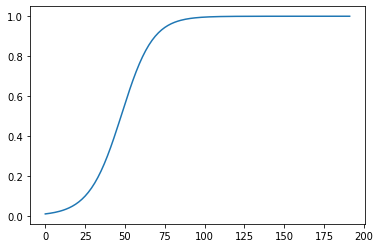

In [83]:
alpha = 1
beta = -1
dt = 0.1
x20 = 0.01

xs = [x20]
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))

plt.plot(xs)
#plt.ylim(None,1.05)
plt.show()

### Stability analysis

#### Phase space

In [57]:
def classify(alpha, beta):
    """Outcome class:
       0 -> strategy 1 dominates (x=0 stable)
       1 -> strategy 2 dominates (x=1 stable)
       2 -> coexistence (interior stable)
       3 -> coordination/bistability (0 and 1 stable)
      -1 -> on axes (alpha=0 or beta=0)
    """
    if alpha < 0 and beta > 0:
        return 0
    if alpha > 0 and beta < 0:
        return 1
    if alpha > 0 and beta > 0:
        return 2
    if alpha < 0 and beta < 0:
        return 3
    return -1

# phase diagram
A = np.linspace(-2, 2, 401)
B = np.linspace(-2, 2, 401)
AA, BB = np.meshgrid(A, B)
Z = np.zeros_like(AA, dtype=float)
for i in range(AA.shape[0]):
    for j in range(AA.shape[1]):
        Z[i, j] = classify(AA[i, j], BB[i, j])

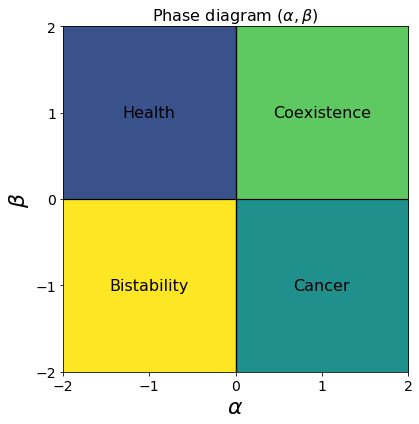

In [143]:
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(Z,origin='lower', extent=[A.min(), A.max(), B.min(), B.max()], aspect='equal')
ax.axhline(0, linewidth=1.2, color='black')
ax.axvline(0, linewidth=1.4, color='black')
ax.set(xticks=np.arange(-2,3),
       yticks=np.arange(-2,3),
       #xlabel=r'$\alpha$',
       #ylabel=r'$\beta$',
       #title=r'Phase diagram $(\alpha,\beta)$'
      )
ax.set_title(r'Phase diagram $(\alpha,\beta)$',fontsize=16)
ax.set_xlabel(r'$\alpha$', fontsize=22)
ax.set_ylabel(r'$\beta$', fontsize=22)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
# or both
#ax.tick_params(labelsize=18)

# text
ax.text(-1, 1, 'Health', fontsize= 16, color='black', ha='center', va='center')
ax.text(1,1, 'Coexistence', fontsize= 16, color='black', ha='center', va='center')
ax.text(-1, -1, 'Bistability', fontsize= 16, color='black', ha='center', va='center')
ax.text(1, -1, 'Cancer', fontsize= 16, color='black', ha='center', va='center')

plt.tight_layout()
plt.savefig('phase_alpha_beta.png', dpi=300)
plt.show()

#### Examples params

In [ ]:
def x_2(x2,alpha,beta,dt):
    return (x2*(1-x2)*(-(alpha+beta)*x2+alpha))*dt + x2

$\alpha<0, \beta>0$

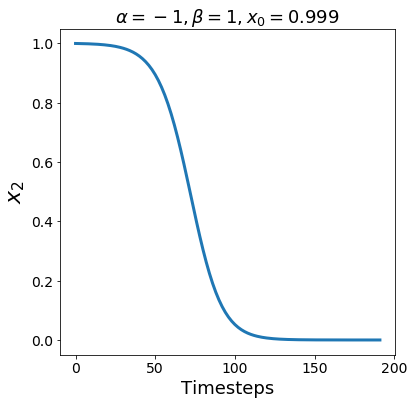

In [197]:
alpha = -1
beta = 1
dt = 0.1
x20 = 0.999

xs = [x20]
fig, ax = plt.subplots(figsize=(6,6))
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))
    
ax.plot(xs,linewidth=3)
ax.set_title(rf'$\alpha={alpha}, \beta={beta}, x_0={x20}$', fontsize=18)
ax.set_xlabel('Timesteps', fontsize=18)
ax.set_ylabel(r'$x_2$', fontsize=22)
ax.tick_params(axis='x',labelsize=14)
ax.tick_params(axis='y',labelsize=14)
#ax.set_ylim(None, 1.05)

plt.savefig(f'2-players_alpha_{alpha}_beta_{beta}.png', dpi=300)
plt.show()

$\alpha>0, \beta<0$

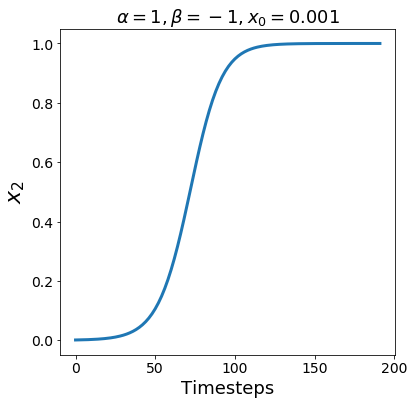

In [198]:
alpha = 1
beta = -1
dt = 0.1
x20 = 0.001

xs = [x20]
fig, ax = plt.subplots(figsize=(6,6))
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))
    
ax.plot(xs,linewidth=3)
ax.set_title(rf'$\alpha={alpha}, \beta={beta}, x_0={x20}$', fontsize=18)
ax.set_xlabel('Timesteps', fontsize=18)
ax.set_ylabel(r'$x_2$', fontsize=22)
ax.tick_params(axis='x',labelsize=14)
ax.tick_params(axis='y',labelsize=14)
#ax.set_ylim(None, 1.05)

plt.savefig(f'2-players_alpha_{alpha}_beta_{beta}.png', dpi=300)
plt.show()

$\alpha>0, \beta>0$

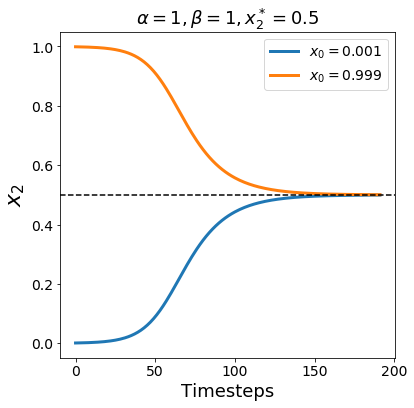

In [199]:
alpha = 1
beta = 1
dt = 0.1
x20_1 = 0.001
x20_2 = 0.999

xs1 = [x20_1]
xs2 = [x20_2]
fig, ax = plt.subplots(figsize=(6,6))
for t in np.arange(1, 20.0001, dt):
    xs1.append(x_2(xs1[-1],alpha,beta,dt))
    xs2.append(x_2(xs2[-1],alpha,beta,dt))
    
ax.plot(xs1,linewidth=3,label=r'$x_0=0.001$')
ax.plot(xs2,linewidth=3,label=r'$x_0=0.999$')


ax.set_title(rf'$\alpha={alpha}, \beta={beta}, x_2^*=0.5$', fontsize=18)
ax.legend(fontsize=14)
ax.axhline((xs1[-1]+xs2[-2])/2,color='black', linestyle='--')

ax.set_xlabel('Timesteps', fontsize=18)
ax.set_ylabel(r'$x_2$', fontsize=22)
ax.tick_params(axis='x',labelsize=14)
ax.tick_params(axis='y',labelsize=14)
ax.set_ylim(None, 1.05)

plt.savefig(f'2-players_alpha_{alpha}_beta_{beta}.png', dpi=300)
plt.show()

$\alpha<0, \beta<0$

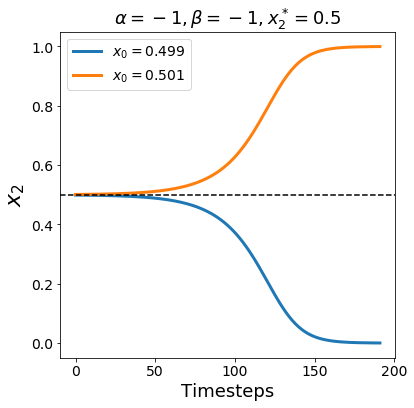

In [200]:
alpha = -1
beta = -1
dt = 0.1
x20_1 = 0.499
x20_2 = 0.501

xs1 = [x20_1]
xs2 = [x20_2]
fig, ax = plt.subplots(figsize=(6,6))
for t in np.arange(1, 20.0001, dt):
    xs1.append(x_2(xs1[-1],alpha,beta,dt))
    xs2.append(x_2(xs2[-1],alpha,beta,dt))
    
ax.plot(xs1,linewidth=3,label=r'$x_0=0.499$')
ax.plot(xs2,linewidth=3,label=r'$x_0=0.501$')


ax.set_title(rf'$\alpha={alpha}, \beta={beta}, x_2^*=0.5$', fontsize=18)
ax.legend(fontsize=14)
ax.axhline((xs1[-1]+xs2[-2])/2,color='black', linestyle='--')

ax.set_xlabel('Timesteps', fontsize=18)
ax.set_ylabel(r'$x_2$', fontsize=22)
ax.tick_params(axis='x',labelsize=14)
ax.tick_params(axis='y',labelsize=14)
ax.set_ylim(None, 1.05)

plt.savefig(f'2-players_alpha_{alpha}_beta_{beta}.png', dpi=300)
plt.show()